# Laboratorio 5: Clasificación de tweets sobre desastres

## Objetivo

El objetivo de este laboratorio es aplicar técnicas de minería de texto para analizar y clasificar tweets. Se busca construir un modelo que determine si un tweet se refiere a un desastre real.

La variable objetivo es `target`:

- `0`: el tweet no se refiere a un desastre real.
- `1`: el tweet se refiere a un desastre real.

A continuación, la descripción del conjunto de datos, limpieza y preprocesamiento del texto, análisis de unigramas y bigramas, y un modelo preliminar de clasificación.

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from wordcloud import WordCloud

In [ ]:
sns.set_theme(style="whitegrid")

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

print("Librerías cargadas correctamente.")
print(f"Cantidad de stopwords en inglés: {len(stop_words)}")

Librerías cargadas correctamente.
Cantidad de stopwords en inglés: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv("data/train.csv")

print("Dimensiones del dataset:", df.shape)
print("Columnas:", df.columns.tolist())

display(df.head())

# Información general
df.info()

Dimensiones del dataset: (7613, 5)
Columnas: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [5]:
summary = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_faltantes": df.isnull().sum(),
    "porcentaje_faltante": (df.isnull().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(summary)

print("Filas duplicadas completas:", df.duplicated().sum())
print("Textos duplicados:", df["text"].duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())

,tipo,valores_faltantes,porcentaje_faltante,valores_unicos
id,int64,0,0.00,7613
keyword,str,61,0.80,221
location,str,2533,33.27,3341
text,str,0,0.00,7503
target,int64,0,0.00,2


Filas duplicadas completas: 0
Textos duplicados: 110
IDs duplicados: 0


In [6]:
duplicated_text_rows = df[
    df.duplicated(subset="text", keep=False)
].sort_values("text")

print(
    "Cantidad total de filas involucradas en textos repetidos:",
    len(duplicated_text_rows)
)

print(
    "Cantidad de textos distintos que se repiten:",
    duplicated_text_rows["text"].nunique()
)

display(
    duplicated_text_rows[
        ["id", "keyword", "location", "text", "target"]
    ].head(20)
)

Cantidad total de filas involucradas en textos repetidos: 179
Cantidad de textos distintos que se repiten: 69


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
6363,9095,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6373,9107,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6377,9113,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6378,9114,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6392,9135,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6366,9098,suicide%20bomb,Nigeria,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2828,4064,displaced,NaN,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1


In [7]:
targets_per_text = df.groupby("text")["target"].nunique()

conflicting_texts = targets_per_text[
    targets_per_text > 1
].index

conflicting_rows = (
    df[df["text"].isin(conflicting_texts)]
    .sort_values(["text", "target"])
)

print(
    "Textos repetidos con etiquetas contradictorias:",
    len(conflicting_texts)
)

print(
    "Filas involucradas en contradicciones:",
    len(conflicting_rows)
)

display(
    conflicting_rows[
        ["id", "keyword", "location", "text", "target"]
    ].head(30)
)

Textos repetidos con etiquetas contradictorias: 18
Filas involucradas en contradicciones: 55


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into ...,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into ...,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into ...,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,0
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #G...,1


In [8]:
duplicate_summary = (
    duplicated_text_rows
    .groupby("target")
    .size()
    .rename("filas_involucradas")
    .reset_index()
)

duplicate_summary["categoría"] = duplicate_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(duplicate_summary)

,target,filas_involucradas,categoría
0,0,58,No desastre
1,1,121,Desastre real


## Descripción y calidad de los datos

El conjunto de datos contiene 7,613 registros y cinco variables. La columna `id` identifica cada tweet; `keyword` contiene una palabra clave asociada; `location` representa la ubicación declarada; `text` contiene el contenido del tweet; y `target` indica si el tweet se relaciona con un desastre real.

La variable `text`, que será la fuente principal de información para el modelo preliminar, no presenta valores faltantes. La columna `keyword` contiene 61 valores faltantes, equivalentes al 0.80 % de los registros, mientras que `location` contiene 2,533 valores faltantes, equivalentes al 33.27 %. Debido a que el modelo preliminar utilizará únicamente el texto, estos valores faltantes no requieren imputación por el momento. Tampoco se eliminarán filas debido a valores faltantes en `keyword` o `location`.

No se encontraron filas completas duplicadas ni identificadores repetidos. Sin embargo, se encontraron 110 repeticiones en la columna `text`. Esto significa que algunos tweets tienen el mismo contenido, pero poseen identificadores distintos o diferencias en otras variables.

Antes de eliminar estos registros es necesario determinar si los textos repetidos tienen la misma clasificación. Si un mismo texto aparece tanto con `target = 0` como con `target = 1`, existe una inconsistencia en las etiquetas. Además, permitir que textos idénticos aparezcan simultáneamente en entrenamiento y prueba podría causar fuga de información y producir métricas demasiado optimistas.

In [10]:
# Eliminar todas las filas cuyos textos tienen etiquetas contradictorias
df_clean = df[
    ~df["text"].isin(conflicting_texts)
].copy()

# Conservar una sola aparición de cada texto restante
df_clean = (
    df_clean
    .drop_duplicates(subset="text", keep="first")
    .reset_index(drop=True)
)

print("Dimensiones originales:", df.shape)
print("Dimensiones después de tratar duplicados:", df_clean.shape)
print("Filas eliminadas:", len(df) - len(df_clean))

print(
    "Textos repetidos restantes:",
    df_clean["text"].duplicated().sum()
)

print(
    "Textos contradictorios restantes:",
    (df_clean.groupby("text")["target"].nunique() > 1).sum()
)

Dimensiones originales: (7613, 5)
Dimensiones después de tratar duplicados: (7485, 5)
Filas eliminadas: 128
Textos repetidos restantes: 0
Textos contradictorios restantes: 0


### Tratamiento de textos repetidos

Se encontraron 179 filas involucradas en repeticiones, correspondientes a 69 textos distintos. Dentro de estos casos, 18 textos presentaban etiquetas contradictorias: el mismo contenido estaba clasificado en algunos registros como desastre real y en otros como no desastre. Estas contradicciones involucraban 55 filas.

Se decidió eliminar todas las apariciones de los textos con etiquetas contradictorias, debido a que no existe una forma objetiva de determinar cuál de las etiquetas es correcta utilizando únicamente la información disponible.

Para los textos repetidos con etiquetas consistentes se conservó una sola aparición. Esta decisión evita que los mismos tweets incrementen artificialmente las frecuencias de palabras y reduce el riesgo de que textos idénticos aparezcan simultáneamente en los conjuntos de entrenamiento y prueba.

Después del tratamiento, el conjunto de datos contiene 7,485 registros, sin textos exactamente repetidos ni textos con etiquetas contradictorias.

In [11]:
target_summary = (
    df_clean["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="cantidad")
)

target_summary["porcentaje"] = (
    target_summary["cantidad"] / len(df_clean) * 100
).round(2)

target_summary["categoría"] = target_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(target_summary)

,target,cantidad,porcentaje,categoría
0,0,4297,57.41,No desastre
1,1,3188,42.59,Desastre real


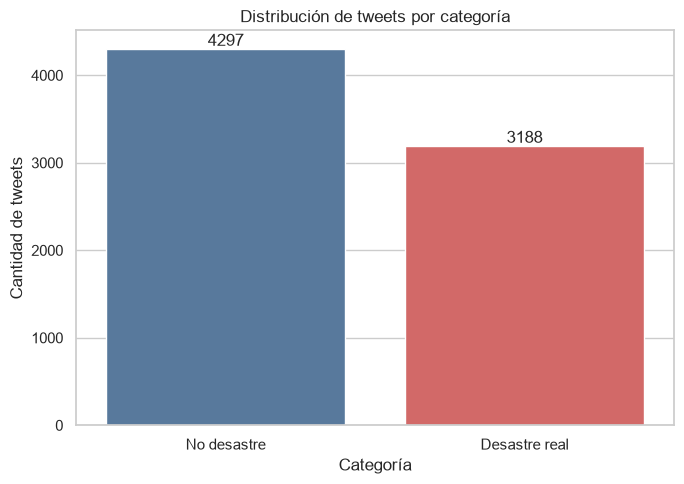

In [12]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x="target",
    hue="target",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False
)

ax.set_title("Distribución de tweets por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de tweets")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No desastre", "Desastre real"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

Después del tratamiento de textos repetidos y contradictorios, el conjunto de datos contiene 7,485 tweets. De ellos, 4,297, equivalentes al 57.41 %, no corresponden a desastres reales. Los 3,188 registros restantes, equivalentes al 42.59 %, sí están relacionados con desastres reales.

La categoría de tweets que no representan desastres es la más frecuente. Sin embargo, la diferencia entre ambas categorías no constituye un desbalance extremo. Para mantener esta proporción en los conjuntos utilizados por el modelo, posteriormente se realizará una división estratificada entre entrenamiento y prueba.

Además del accuracy, se utilizarán precision, recall y F1-score para evaluar el modelo, debido a que estas métricas permiten analizar su comportamiento en cada categoría.

In [13]:
df_clean["character_count"] = (
    df_clean["text"]
    .astype(str)
    .str.len()
)

df_clean["word_count"] = (
    df_clean["text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df_clean[
        ["text", "character_count", "word_count", "target"]
    ].head()
)

,text,character_count,word_count,target
0,Our Deeds are the Reason of this #earthquake M...,69,13,1
1,Forest fire near La Ronge Sask. Canada,38,7,1
2,All residents asked to 'shelter in place' are ...,133,22,1
3,"13,000 people receive #wildfires evacuation or...",65,8,1
4,Just got sent this photo from Ruby #Alaska as ...,88,16,1


In [14]:
length_summary = (
    df_clean
    .groupby("target")
    .agg(
        tweets=("text", "count"),
        media_caracteres=("character_count", "mean"),
        mediana_caracteres=("character_count", "median"),
        minimo_caracteres=("character_count", "min"),
        maximo_caracteres=("character_count", "max"),
        media_palabras=("word_count", "mean"),
        mediana_palabras=("word_count", "median"),
        minimo_palabras=("word_count", "min"),
        maximo_palabras=("word_count", "max")
    )
    .round(2)
    .reset_index()
)

length_summary["categoría"] = length_summary["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

display(length_summary)

,target,tweets,media_caracteres,mediana_caracteres,minimo_caracteres,maximo_caracteres,media_palabras,mediana_palabras,minimo_palabras,maximo_palabras,categoría
0,0,4297,95.58,101.0,7,157,14.67,15.0,1,31,No desastre
1,1,3188,108.02,114.0,14,151,15.14,15.0,2,30,Desastre real


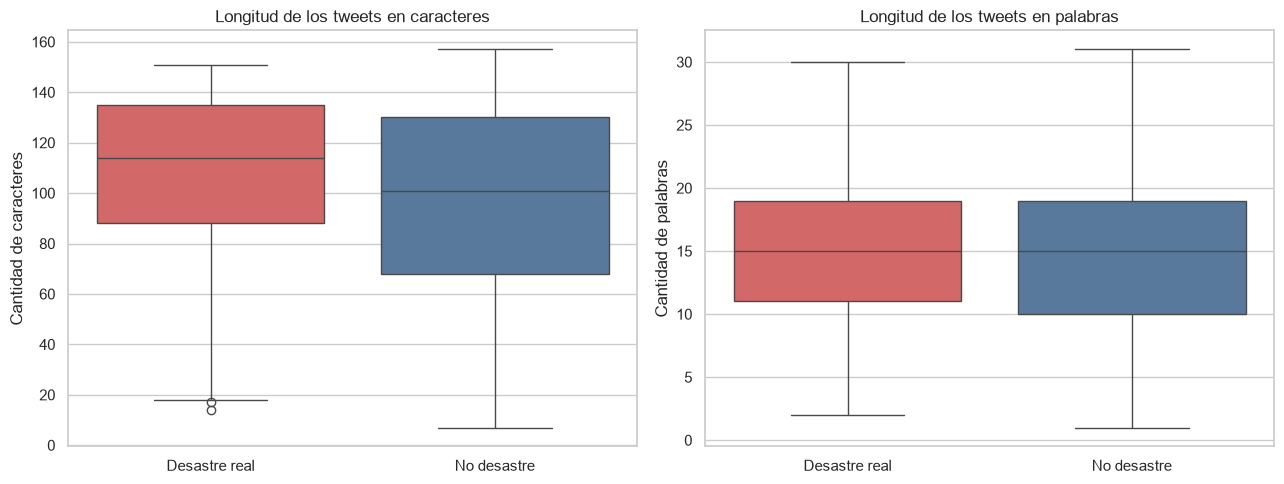

In [15]:
plot_df = df_clean.copy()

plot_df["categoría"] = plot_df["target"].map({
    0: "No desastre",
    1: "Desastre real"
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=plot_df,
    x="categoría",
    y="character_count",
    hue="categoría",
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Longitud de los tweets en caracteres")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad de caracteres")

sns.boxplot(
    data=plot_df,
    x="categoría",
    y="word_count",
    hue="categoría",
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Longitud de los tweets en palabras")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad de palabras")

plt.tight_layout()
plt.show()

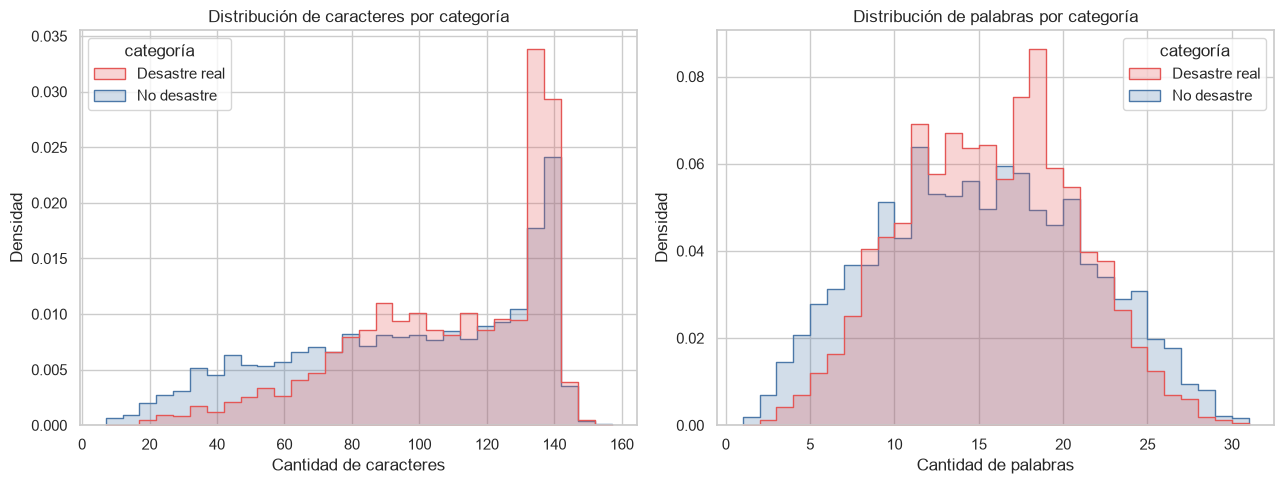

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=plot_df,
    x="character_count",
    hue="categoría",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    ax=axes[0]
)

axes[0].set_title("Distribución de caracteres por categoría")
axes[0].set_xlabel("Cantidad de caracteres")
axes[0].set_ylabel("Densidad")

sns.histplot(
    data=plot_df,
    x="word_count",
    hue="categoría",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No desastre": "#4C78A8",
        "Desastre real": "#E45756"
    },
    ax=axes[1]
)

axes[1].set_title("Distribución de palabras por categoría")
axes[1].set_xlabel("Cantidad de palabras")
axes[1].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

### Longitud de los tweets

Los tweets relacionados con desastres reales presentan una longitud media de 108.02 caracteres y una mediana de 114 caracteres. En cambio, los tweets que no corresponden a desastres tienen una media de 95.58 caracteres y una mediana de 101 caracteres. Por lo tanto, los tweets sobre desastres tienden a ser más extensos en cantidad de caracteres.

La diferencia en cantidad de palabras es menor. Los tweets sobre desastres contienen en promedio 15.14 palabras, mientras que los tweets que no representan desastres contienen 14.67. Ambas categorías presentan una mediana de 15 palabras.

Los histogramas muestran un solapamiento considerable entre las categorías, especialmente en la cantidad de palabras. Esto indica que la longitud por sí sola no permitiría clasificar correctamente los tweets. Sin embargo, la mayor cantidad de caracteres observada en los tweets sobre desastres puede considerarse una característica potencialmente informativa.

La diferencia entre caracteres y palabras también puede deberse a la presencia de palabras más largas, hashtags, enlaces y detalles específicos en los tweets relacionados con desastres.